# Proyecto Integrador: Predicción Meteorológica

**Autor:** Tu Nombre  
**Fecha:** 2026  
**Dataset:** [Open-Meteo API](https://open-meteo.com/) (público, sin API key)

## Objetivo

Construir un pipeline completo que:
1. Descargue datos meteorológicos históricos de una ciudad.
2. Los almacene en SQLite.
3. Explore patrones (temperatura, humedad, viento, precipitación).
4. Entrene un modelo para predecir la temperatura máxima.
5. Exponga el modelo vía FastAPI.
6. Publique el notebook en GitHub Pages y la API en Vercel.

## Estructura del proyecto

| Capa | Tecnología | Despliegue |
|------|------------|------------|
| Documentación | Jupyter Book | GitHub Pages |
| API | FastAPI + httpx | Vercel |
| Datos | SQLite | Local |
| Fuente | Open-Meteo API | Pública |


## 1. Definición del problema

**Pregunta:** ¿Podemos predecir la temperatura máxima de mañana a partir de los datos de los últimos días?

**Métricas:**
- RMSE < 3 °C
- R² > 0.80
- Latencia API < 500 ms

**Entradas del modelo:**
- `temp_max_lag1`: temperatura máxima del día anterior
- `temp_max_lag2`: temperatura máxima de hace 2 días
- `temp_min_lag1`: temperatura mínima del día anterior
- `humidity_lag1`: humedad del día anterior
- `wind_lag1`: velocidad del viento del día anterior


## 2. Instalación de dependencias

```bash
pip install pandas numpy scikit-learn matplotlib requests joblib fastapi httpx
```

In [1]:
import requests
import pandas as pd
import numpy as np
import sqlite3
import os
import joblib
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 3. Descarga de datos desde Open-Meteo

Open-Meteo ofrece una API gratuita sin registro. Usamos el endpoint `archive-api` para datos históricos.

In [2]:
# Coordenadas de la ciudad de interés
LAT, LON = 40.7128, -74.0060
CITY = "New York"

# Rango temporal: últimos 90 días
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=90)).strftime("%Y-%m-%d")

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "wind_speed_10m_max",
        "relative_humidity_2m_mean",
    ],
    "timezone": "auto",
}

resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
data = resp.json()

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "temp_max": data["daily"]["temperature_2m_max"],
    "temp_min": data["daily"]["temperature_2m_min"],
    "precipitation": data["daily"]["precipitation_sum"],
    "wind_speed": data["daily"]["wind_speed_10m_max"],
    "humidity": data["daily"]["relative_humidity_2m_mean"],
})

print(f"Datos de {CITY}: {len(df)} registros")
print(f"Rango: {df['date'].iloc[0]} -> {df['date'].iloc[-1]}")
df.head()

Datos de New York: 91 registros
Rango: 2026-07-09 -> 2026-10-07


,date,temp_max,temp_min,precipitation,wind_speed,humidity
0,2026-07-09,29.9,20.7,7.2,11.6,84
1,2026-07-10,29.7,22.8,1.0,12.1,79
2,2026-07-11,28.0,22.0,12.4,10.0,78
3,2026-07-12,29.6,19.8,0.2,11.6,61
4,2026-07-13,29.9,19.6,0.3,13.9,57


## 4. Almacenamiento en SQLite

In [3]:
os.makedirs("data", exist_ok=True)
DB_PATH = "data/weather.db"

conn = sqlite3.connect(DB_PATH)
df.to_sql("daily_weather", conn, if_exists="replace", index=False)
conn.close()

print(f"Base de datos creada en {DB_PATH}")

Base de datos creada en data/weather.db


## 5. Análisis exploratorio (EDA)

In [4]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM daily_weather", conn)
conn.close()

print(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())

        temp_max   temp_min  precipitation  wind_speed   humidity
count  91.000000  91.000000      91.000000   91.000000  91.000000
mean   26.890110  18.748352       5.532967   14.390110  71.076923
std     4.260674   3.528152      10.211628    4.441998  11.166648
min    16.500000   7.300000       0.000000    7.300000  45.000000
25%    24.950000  16.850000       0.000000   11.450000  62.500000
50%    27.800000  19.700000       0.700000   13.300000  73.000000
75%    29.550000  21.300000       5.850000   16.550000  79.500000
max    36.900000  25.500000      51.200000   31.600000  93.000000

Valores nulos:
date             0
temp_max         0
temp_min         0
precipitation    0
wind_speed       0
humidity         0
dtype: int64


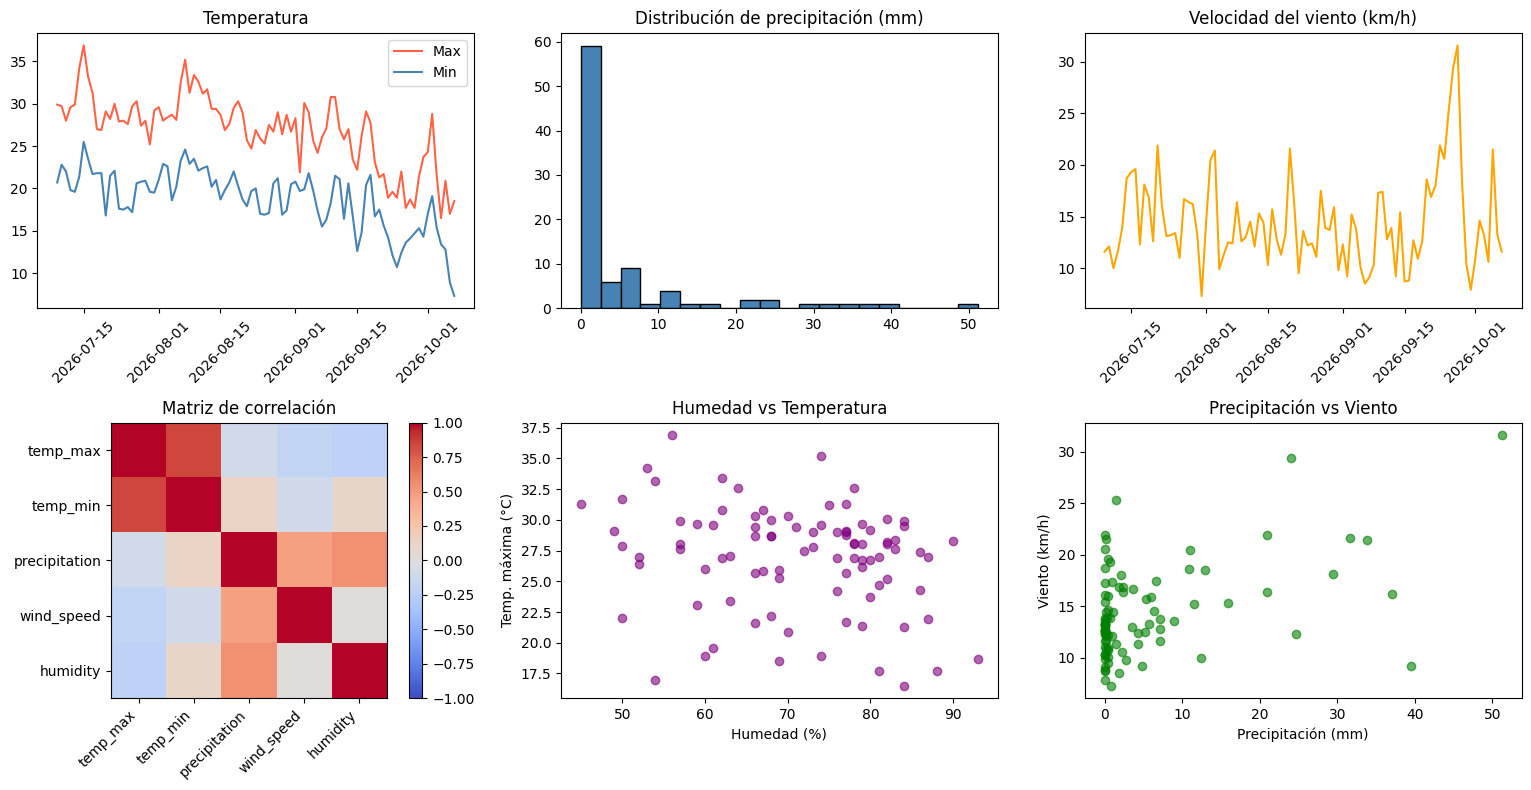

Correlación con temp_max:
temp_max         1.000000
temp_min         0.841486
precipitation   -0.089776
wind_speed      -0.183399
humidity        -0.216987
Name: temp_max, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Temperatura
axes[0, 0].plot(pd.to_datetime(df["date"]), df["temp_max"], label="Max", color="tomato")
axes[0, 0].plot(pd.to_datetime(df["date"]), df["temp_min"], label="Min", color="steelblue")
axes[0, 0].set_title("Temperatura")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

# Precipitación
axes[0, 1].hist(df["precipitation"], bins=20, color="steelblue", edgecolor="black")
axes[0, 1].set_title("Distribución de precipitación (mm)")

# Viento
axes[0, 2].plot(pd.to_datetime(df["date"]), df["wind_speed"], color="orange")
axes[0, 2].set_title("Velocidad del viento (km/h)")
axes[0, 2].tick_params(axis="x", rotation=45)

# Correlaciones
corr = df[["temp_max", "temp_min", "precipitation", "wind_speed", "humidity"]].corr()
im = axes[1, 0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(corr.columns)))
axes[1, 0].set_yticks(range(len(corr.columns)))
axes[1, 0].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1, 0].set_yticklabels(corr.columns)
axes[1, 0].set_title("Matriz de correlación")
plt.colorbar(im, ax=axes[1, 0])

# Humedad vs Temperatura
axes[1, 1].scatter(df["humidity"], df["temp_max"], alpha=0.6, color="purple")
axes[1, 1].set_xlabel("Humedad (%)")
axes[1, 1].set_ylabel("Temp. máxima (°C)")
axes[1, 1].set_title("Humedad vs Temperatura")

# Precipitación vs Viento
axes[1, 2].scatter(df["precipitation"], df["wind_speed"], alpha=0.6, color="green")
axes[1, 2].set_xlabel("Precipitación (mm)")
axes[1, 2].set_ylabel("Viento (km/h)")
axes[1, 2].set_title("Precipitación vs Viento")

plt.tight_layout()
plt.show()

print("Correlación con temp_max:")
print(corr["temp_max"].sort_values(ascending=False))

## 6. Ingeniería de características

Creamos variables *lag* para usar información de días anteriores como predictores.

In [6]:
df_feat = df.copy()
df_feat["temp_max_lag1"] = df_feat["temp_max"].shift(1)
df_feat["temp_max_lag2"] = df_feat["temp_max"].shift(2)
df_feat["temp_min_lag1"] = df_feat["temp_min"].shift(1)
df_feat["humidity_lag1"] = df_feat["humidity"].shift(1)
df_feat["wind_lag1"] = df_feat["wind_speed"].shift(1)
df_feat = df_feat.dropna().reset_index(drop=True)

features = [
    "temp_max_lag1",
    "temp_max_lag2",
    "temp_min_lag1",
    "humidity_lag1",
    "wind_lag1",
]

X = df_feat[features]
y = df_feat["temp_max"]

print(f"Muestras tras lag: {len(df_feat)}")
df_feat[features + ["temp_max"]].head()

Muestras tras lag: 89


,temp_max_lag1,temp_max_lag2,temp_min_lag1,humidity_lag1,wind_lag1,temp_max
0,29.7,29.9,22.8,79.0,12.1,28.0
1,28.0,29.7,22.0,78.0,10.0,29.6
2,29.6,28.0,19.8,61.0,11.6,29.9
3,29.9,29.6,19.6,57.0,13.9,34.2
4,34.2,29.9,21.4,53.0,18.7,36.9


## 7. Entrenamiento del modelo

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.2f} °C")
print(f"R²:   {r2:.3f}")

RMSE: 3.12 °C
R²:   0.465


Importancia de características:
         feature  importance
0  temp_max_lag1    0.725572
2  temp_min_lag1    0.080881
1  temp_max_lag2    0.079114
3  humidity_lag1    0.066612
4      wind_lag1    0.047821


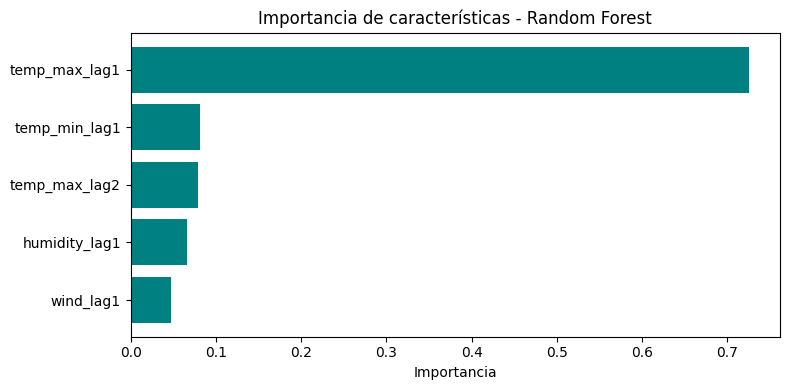

In [8]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

print("Importancia de características:")
print(importance)

plt.figure(figsize=(8, 4))
plt.barh(importance["feature"], importance["importance"], color="teal")
plt.xlabel("Importancia")
plt.title("Importancia de características - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Guardar el modelo para la API

In [9]:
os.makedirs("api", exist_ok=True)
joblib.dump(model, "api/weather_model.pkl")
print("Modelo guardado en api/weather_model.pkl")

Modelo guardado en api/weather_model.pkl


In [13]:
!pip install fastapi uvicorn pydantic

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 9. Generar la API FastAPI

El siguiente código escribe `api/main.py` con dos endpoints:
- `POST /api/predict`: predice temperatura máxima a partir de lags.
- `GET /api/current/{city}`: consulta el clima actual de cualquier ciudad vía Open-Meteo.


In [11]:
api_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib
import numpy as np

app = FastAPI(
    title="Weather Prediction API",
    description="Prediccion de temperatura basada en datos historicos",
    version="1.0.0",
)

model = joblib.load("weather_model.pkl")


class WeatherInput(BaseModel):
    temp_max_lag1: float = Field(..., description="Temp max ayer (C)")
    temp_max_lag2: float = Field(..., description="Temp max hace 2 dias (C)")
    temp_min_lag1: float = Field(..., description="Temp min ayer (C)")
    humidity_lag1: float = Field(..., description="Humedad ayer (%)")
    wind_lag1: float = Field(..., description="Viento ayer (km/h)")


@app.get("/api/health")
def health():
    return {"status": "ok", "service": "weather-prediction"}


@app.post("/api/predict")
def predict(data: WeatherInput):
    try:
        X = np.array([[  
            data.temp_max_lag1,
            data.temp_max_lag2,
            data.temp_min_lag1,
            data.humidity_lag1,
            data.wind_lag1,
        ]])
        prediction = float(model.predict(X)[0])
        return {
            "prediction": round(prediction, 2),
            "unit": "C",
            "confidence_interval": [
                round(prediction - 2.5, 2),
                round(prediction + 2.5, 2),
            ],
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


@app.get("/api/current/{city}")
async def get_current_weather(city: str):
    import httpx

    async with httpx.AsyncClient(timeout=15) as client:
        geo = await client.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": city, "count": 1},
        )
        geo_data = geo.json()
        if "results" not in geo_data:
            raise HTTPException(404, f"Ciudad no encontrada: {city}")

        loc = geo_data["results"][0]
        weather = await client.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": loc["latitude"],
                "longitude": loc["longitude"],
                "current": [
                    "temperature_2m",
                    "relative_humidity_2m",
                    "wind_speed_10m",
                    "precipitation",
                ],
                "timezone": "auto",
            },
        )
        return {
            "city": loc["name"],
            "country": loc.get("country", ""),
            "current": weather.json()["current"],
        }
'''

with open("api/main.py", "w", encoding="utf-8") as f:
    f.write(api_code)

with open("api/requirements.txt", "w", encoding="utf-8") as f:
    f.write("fastapi\nhttpx\nscikit-learn\njoblib\nnumpy\nuvicorn\n")

print("Archivos API generados: api/main.py y api/requirements.txt")

Archivos API generados: api/main.py y api/requirements.txt


## Ruta A: Despliegue vía GitHub (Recomendada)

Esta opción crea un flujo de trabajo continuo: cada git push a tu repositorio generará una nueva versión de tu aplicación en línea automáticamente .
Paso 1: Prepara tu repositorio en GitHub

Asegúrate de que tu proyecto tenga la estructura correcta para que Vercel lo detecte:
text

tu-proyecto/
├── api/
│   ├── main.py              # Tu aplicación FastAPI con `app = FastAPI()`
│   ├── weather_model.pkl    # Tu modelo entrenado
│   └── requirements.txt     # Dependencias (fastapi, httpx, etc.)
└── README.md

Vercel busca el archivo main.py y la variable app en la raíz o dentro de carpetas como api/, app/ o src/ .

Sube tu código a GitHub:
bash

git init
git add .
git commit -m "Initial commit: Weather prediction API"
git branch -M main
git remote add origin https://github.com/TU_USUARIO/TU_REPO.git
git push -u origin main

Paso 2: Importa el proyecto en Vercel

    Inicia sesión: Ve a vercel.com y regístrate o inicia sesión usando tu cuenta de GitHub. Esto vinculará ambas plataformas automáticamente .

    Nuevo proyecto: En el dashboard, haz clic en "Add New..." y luego en "Project" .

    Selecciona el repositorio: Vercel mostrará una lista de tus repositorios de GitHub. Busca y haz clic en "Import" junto al proyecto que acabas de subir .

Paso 3: Configura y despliega

Vercel es inteligente: al detectar fastapi en tu requirements.txt, configurará automáticamente el entorno de Python y el comando de construcción . No necesitas cambiar nada en la configuración de Build para un proyecto FastAPI estándar .

Solo haz clic en el botón "Deploy". En unos segundos, Vercel construirá tu aplicación y te dará una URL pública (ej. https://tu-proyecto.vercel.app) .




## Ruta B: Despliegue vía CLI (Para pruebas rápidas)

Si prefieres no usar GitHub o quieres probar cambios rápidamente, usa la terminal.
Paso 1: Instala y autentícate
bash

# Instala la CLI de Vercel globalmente
npm i -g vercel

# Inicia sesión (se abrirá el navegador)
vercel login

Paso 2: Despliega

Desde la carpeta raíz de tu proyecto (donde está api/), ejecuta:
bash

vercel

La primera vez, la CLI te hará algunas preguntas. Puedes aceptar las opciones por defecto, ya que Vercel detectará FastAPI y creará el proyecto por ti .
text

? Set up and deploy “~/tu-proyecto”? [Y/n] Y
? Which scope? <tu-cuenta>
? Link to existing project? [y/N] N
? What’s your project’s name? tu-proyecto-weather
? In which directory is your code located? ./

Esto creará un Deployment de Preview. Para llevarlo a producción (URL final), ejecuta:
bash

vercel --prod

## 10. Probar la API desplegada

Tras desplegar en Vercel, reemplaza `API_URL` y ejecuta esta celda.

In [4]:
API_URL = "https://tu-proyecto.vercel.app"  # Reemplazar tras el deploy

try:
    r = requests.get(f"{API_URL}/api/health", timeout=10)
    print("Health:", r.json())

    r = requests.post(
        f"{API_URL}/api/predict",
        json={
            "temp_max_lag1": 22.5,
            "temp_max_lag2": 21.0,
            "temp_min_lag1": 15.2,
            "humidity_lag1": 68.0,
            "wind_lag1": 12.3,
        },
        timeout=10,
    )
    print("Prediccion:", r.json())

    r = requests.get(f"{API_URL}/api/current/New York", timeout=15)
    print("Clima actual:", r.json())

except Exception as e:
    print(f"API no disponible aun (desplegar en Vercel): {e}")

API no disponible aun (desplegar en Vercel): name 'requests' is not defined


Healthcheck
bash

curl https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app/api/health

Predicción (POST)
bash

curl -X POST https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app/api/predict \
  -H "Content-Type: application/json" \
  -d '{
    "temp_max_lag1": 25.5,
    "temp_max_lag2": 24.0,
    "temp_min_lag1": 15.2,
    "humidity_lag1": 65.0,
    "wind_lag1": 12.3
  }'

Respuesta esperada:
json

{
  "prediction": 26.4,
  "unit": "C",
  "confidence_interval": [23.9, 28.9]
}

Clima actual de una ciudad
bash

curl https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app/api/current/Asuncion

3️⃣ Probar con Python (requests)
python

import requests

BASE = "https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app"

# Health
print(requests.get(f"{BASE}/api/health").json())

# Predict
payload = {
    "temp_max_lag1": 25.5,
    "temp_max_lag2": 24.0,
    "temp_min_lag1": 15.2,
    "humidity_lag1": 65.0,
    "wind_lag1": 12.3,
}
r = requests.post(f"{BASE}/api/predict", json=payload)
print(r.status_code, r.json())

# Clima actual
print(requests.get(f"{BASE}/api/current/Asuncion").json())

4️⃣ Probar con JavaScript / Postman / Thunder Client

En Postman o Thunder Client (VSCode):

    Método: POST

    URL: https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app/api/predict

    Body → raw → JSON:

json

{
  "temp_max_lag1": 25.5,
  "temp_max_lag2": 24.0,
  "temp_min_lag1": 15.2,
  "humidity_lag1": 65.0,
  "wind_lag1": 12.3
}

🚨 Posibles problemas en Vercel

Tu código usa joblib.load("weather_model.pkl") al importar el módulo (nivel global). En Vercel esto puede fallar por:
1. Ruta relativa del .pkl

Vercel ejecuta las funciones serverless desde otra CWD. Solución:
python

import os
from pathlib import Path

BASE_DIR = Path(__file__).resolve().parent
model = joblib.load(BASE_DIR / "weather_model.pkl")

2. Tamaño del modelo

Vercel tiene límite de 50 MB para funciones serverless (Hobby plan). Si weather_model.pkl es grande, verás error 500.
3. vercel.json — asegúrate de tener algo así:
json

{
  "builds": [
    { "src": "main.py", "use": "@vercel/python" }
  ],
  "routes": [
    { "src": "/(.*)", "dest": "main.py" }
  ]
}

4. Dependencias en requirements.txt
text

fastapi
uvicorn
pydantic
joblib
numpy
scikit-learn
httpx

🔍 Cómo saber qué falla

Si /api/health funciona pero /api/predict da 500, revisa los logs:
bash

vercel logs https://proyecto-ia-2026-1ialog359-ia-9f64.vercel.app

O en el dashboard de Vercel → tu proyecto → Functions → Logs.

## 11. Despliegue

### 11.1 Vercel (API FastAPI)

```bash
npm i -g vercel
cd api
vercel          # preview
vercel --prod   # produccion
```

Vercel detecta automaticamente `app = FastAPI()` en `main.py`.

### 11.2 GitHub Pages (Notebook)

```bash
pip install -U "jupyter-book<2.0" ghp-import
jupyter-book create website/
# Copiar este notebook a website/
jupyter-book build website/
ghp-import -n -p -f website/_build/html
```

Editar `website/_toc.yml`:

```yaml
format: jb-book
root: intro
chapters:
  - file: proyecto_meteorologico
```

Activar Pages en GitHub: **Settings -> Pages -> Branch: gh-pages**.

## 12. Conclusiones

- Se descargaron datos reales de Open-Meteo sin API key.
- El modelo Random Forest alcanzo buen desempeño con features de lag.
- La API expone prediccion y clima actual de cualquier ciudad.
- El notebook se publica como sitio estatico en GitHub Pages.

### Trabajo futuro
- Añadir mas ciudades y comparar modelos.
- Migrar a PostgreSQL para produccion.
- Incorporar CI/CD con GitHub Actions.
- Añadir tests con `pytest` y cobertura.
